# Kalenjin ASR: Data Verification & Audio Exploration

**Purpose**: Verify preprocessed data quality before training

## Objectives:
1. Load and inspect preprocessed dataset
2. Listen to sample audio files
3. Verify text transcriptions
4. Validate vocabulary mapping
5. Check data statistics

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from datasets import load_from_disk
import json
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path
from IPython.display import Audio, display, HTML

print("✓ Libraries loaded")

✓ Libraries loaded


## 2. Load Dataset & Vocabulary

In [2]:
# Load preprocessed dataset
dataset = load_from_disk('../processed_data/kalenjin_asr_dataset')

# Load vocabulary
with open('../processed_data/vocab.json', 'r') as f:
    vocab = json.load(f)

print(f"Dataset splits: {list(dataset.keys())}")
print(f"\nTrain samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples: {len(dataset['test'])}")
print(f"\nVocabulary size: {len(vocab)}")

Dataset splits: ['train', 'validation', 'test']

Train samples: 11057
Validation samples: 6409
Test samples: 5675

Vocabulary size: 32


## 3. Inspect Vocabulary

In [3]:
print("Vocabulary Mapping:")
print("="*50)
for token, idx in sorted(vocab.items(), key=lambda x: x[1]):
    display_token = repr(token) if token in [' ', '|'] or token.startswith('[') else token
    print(f"{idx:>2}: {display_token}")

Vocabulary Mapping:
 0: '[PAD]'
 1: '[UNK]'
 2: '[CTC]'
 3: '|'
 4: ' '
 5: '
 6: a
 7: b
 8: c
 9: d
10: e
11: f
12: g
13: h
14: i
15: j
16: k
17: l
18: m
19: n
20: o
21: p
22: q
23: r
24: s
25: t
26: u
27: v
28: w
29: x
30: y
31: z


## 4. Sample Audio Exploration

Sample 0 from train set

Transcription: tomo itinye coruet ne cepto iman
Duration: 2.14s
SNR: 45.9 dB
Sample rate: 16000 Hz
Audio shape: (65088,)

🔊 Audio Player:


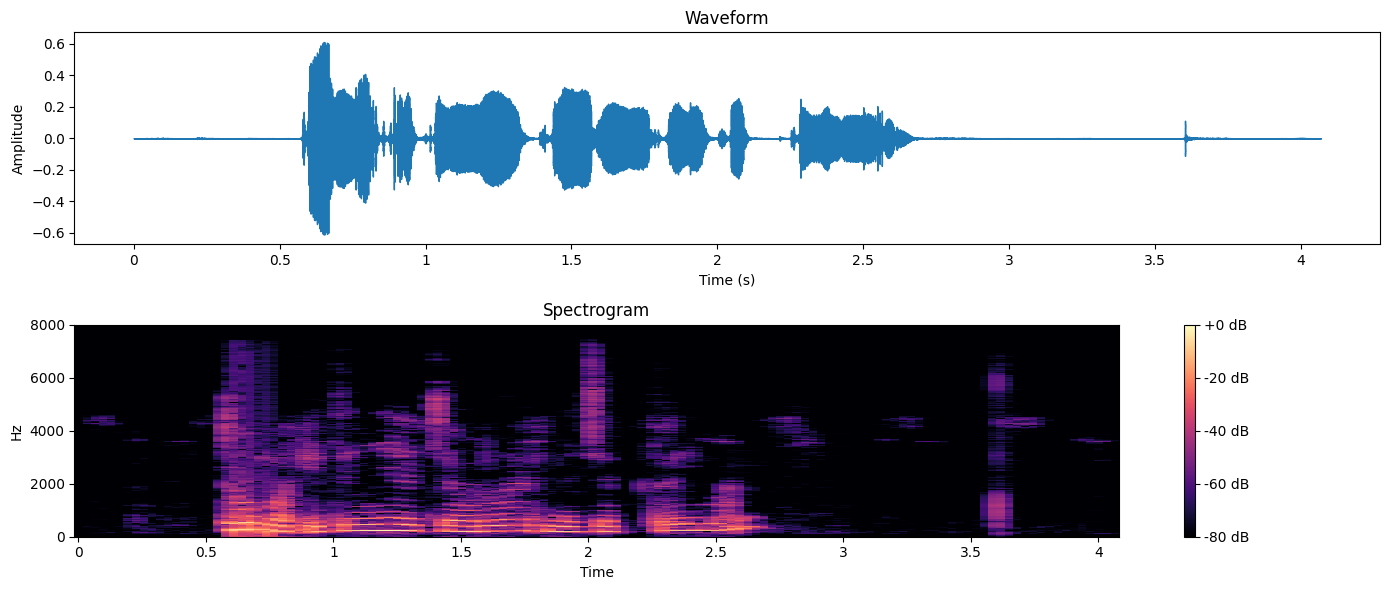

In [4]:
# Function to display audio sample
def explore_sample(dataset, split='train', idx=0):
    sample = dataset[split][idx]
    
    print("="*70)
    print(f"Sample {idx} from {split} set")
    print("="*70)
    print(f"\nTranscription: {sample['text']}")
    print(f"Duration: {sample['duration']:.2f}s")
    print(f"SNR: {sample['snr_db']:.1f} dB")
    
    # Get audio
    audio_array = sample['audio']['array']
    sr = sample['audio']['sampling_rate']
    
    print(f"Sample rate: {sr} Hz")
    print(f"Audio shape: {audio_array.shape}")
    
    # Display audio player
    print("\n🔊 Audio Player:")
    display(Audio(audio_array, rate=sr))
    
    # Plot waveform
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    
    # Waveform
    librosa.display.waveshow(audio_array, sr=sr, ax=axes[0])
    axes[0].set_title('Waveform')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    
    # Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_array)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1])
    axes[1].set_title('Spectrogram')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()
    
    return sample

# Explore first sample
sample = explore_sample(dataset, 'train', 0)

## 5. Explore Multiple Samples

In [5]:
# Explore 5 random samples
import random

print("\n" + "="*70)
print("EXPLORING 5 RANDOM SAMPLES")
print("="*70)

indices = random.sample(range(len(dataset['train'])), 5)

for i, idx in enumerate(indices, 1):
    print(f"\n{'='*70}")
    print(f"Sample {i}/5 (Index: {idx})")
    print(f"{'='*70}")
    
    sample = dataset['train'][idx]
    print(f"Text: {sample['text']}")
    print(f"Duration: {sample['duration']:.2f}s | SNR: {sample['snr_db']:.1f}dB")
    
    # Audio player
    audio_array = sample['audio']['array']
    sr = sample['audio']['sampling_rate']
    display(Audio(audio_array, rate=sr))


EXPLORING 5 RANDOM SAMPLES

Sample 1/5 (Index: 3858)
Text: kimeto kwanda nyij eng koot eng saenyi
Duration: 3.81s | SNR: 81.3dB



Sample 2/5 (Index: 7601)
Text: ngotomo inemu korotik komecei itinye beek cecang eng borto
Duration: 3.39s | SNR: 41.9dB



Sample 3/5 (Index: 5627)
Text: kakoyosit bomori ne nyun nea
Duration: 1.47s | SNR: 46.8dB



Sample 4/5 (Index: 3689)
Text: kiunigei komakipa rutoi
Duration: 2.34s | SNR: 84.4dB



Sample 5/5 (Index: 5889)
Text: poipoiyet kopunu aritit ap mukuleldo
Duration: 2.75s | SNR: 48.7dB


## 6. Dataset Statistics

In [6]:
# Compute statistics
def compute_stats(dataset, split='train'):
    durations = [s['duration'] for s in dataset[split]]
    snrs = [s['snr_db'] for s in dataset[split]]
    text_lengths = [len(s['text']) for s in dataset[split]]
    
    print(f"\n{split.upper()} SET STATISTICS")
    print("="*50)
    print(f"Total samples: {len(dataset[split])}")
    print(f"\nDuration (seconds):")
    print(f"  Mean: {np.mean(durations):.2f}")
    print(f"  Std: {np.std(durations):.2f}")
    print(f"  Min: {np.min(durations):.2f}")
    print(f"  Max: {np.max(durations):.2f}")
    print(f"  Total: {np.sum(durations)/3600:.2f} hours")
    
    print(f"\nSNR (dB):")
    print(f"  Mean: {np.mean(snrs):.2f}")
    print(f"  Std: {np.std(snrs):.2f}")
    print(f"  Min: {np.min(snrs):.2f}")
    print(f"  Max: {np.max(snrs):.2f}")
    
    print(f"\nText Length (characters):")
    print(f"  Mean: {np.mean(text_lengths):.2f}")
    print(f"  Std: {np.std(text_lengths):.2f}")
    print(f"  Min: {np.min(text_lengths)}")
    print(f"  Max: {np.max(text_lengths)}")
    
    return durations, snrs, text_lengths

# Compute for all splits
train_stats = compute_stats(dataset, 'train')
val_stats = compute_stats(dataset, 'validation')
test_stats = compute_stats(dataset, 'test')


TRAIN SET STATISTICS
Total samples: 11057

Duration (seconds):
  Mean: 2.84
  Std: 1.30
  Min: 0.51
  Max: 12.03
  Total: 8.71 hours

SNR (dB):
  Mean: 50.67
  Std: 14.90
  Min: 27.54
  Max: 89.64

Text Length (characters):
  Mean: 39.64
  Std: 15.42
  Min: 4
  Max: 115

VALIDATION SET STATISTICS
Total samples: 6409

Duration (seconds):
  Mean: 3.02
  Std: 1.42
  Min: 0.58
  Max: 11.71
  Total: 5.38 hours

SNR (dB):
  Mean: 48.92
  Std: 13.26
  Min: 25.78
  Max: 90.67

Text Length (characters):
  Mean: 36.88
  Std: 13.95
  Min: 7
  Max: 107

TEST SET STATISTICS
Total samples: 5675

Duration (seconds):
  Mean: 3.89
  Std: 2.17
  Min: 0.51
  Max: 15.02
  Total: 6.13 hours

SNR (dB):
  Mean: 55.50
  Std: 12.07
  Min: 27.97
  Max: 87.63

Text Length (characters):
  Mean: 41.49
  Std: 17.05
  Min: 3
  Max: 115


## 7. Visualize Distributions

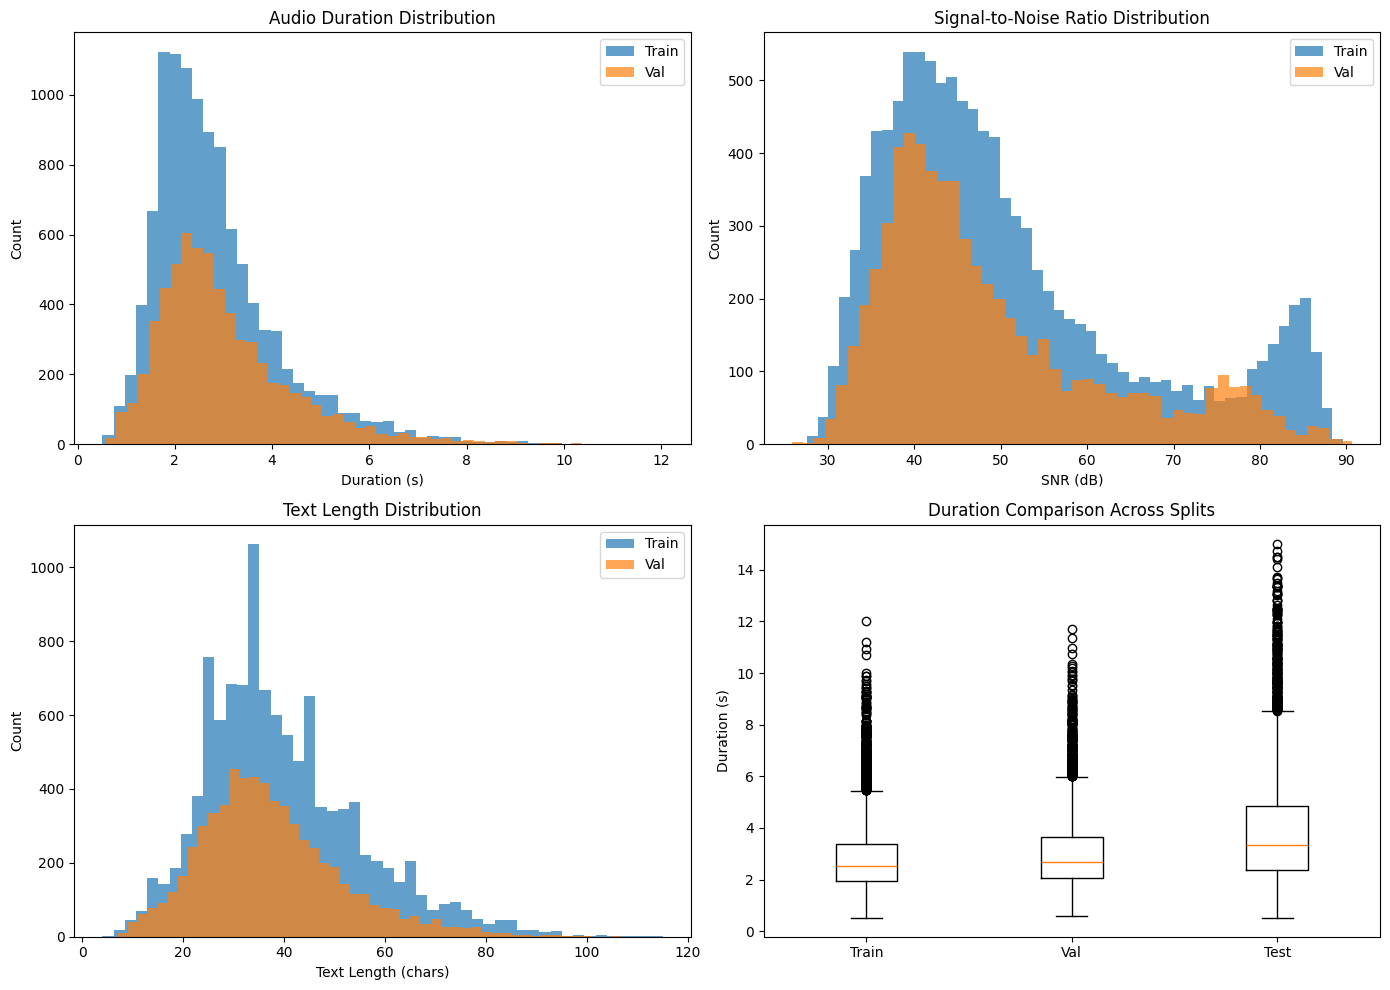

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Duration distribution
axes[0, 0].hist(train_stats[0], bins=50, alpha=0.7, label='Train')
axes[0, 0].hist(val_stats[0], bins=50, alpha=0.7, label='Val')
axes[0, 0].set_xlabel('Duration (s)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Audio Duration Distribution')
axes[0, 0].legend()

# SNR distribution
axes[0, 1].hist(train_stats[1], bins=50, alpha=0.7, label='Train')
axes[0, 1].hist(val_stats[1], bins=50, alpha=0.7, label='Val')
axes[0, 1].set_xlabel('SNR (dB)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Signal-to-Noise Ratio Distribution')
axes[0, 1].legend()

# Text length distribution
axes[1, 0].hist(train_stats[2], bins=50, alpha=0.7, label='Train')
axes[1, 0].hist(val_stats[2], bins=50, alpha=0.7, label='Val')
axes[1, 0].set_xlabel('Text Length (chars)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Text Length Distribution')
axes[1, 0].legend()

# Box plot comparison
axes[1, 1].boxplot([train_stats[0], val_stats[0], test_stats[0]], 
                    labels=['Train', 'Val', 'Test'])
axes[1, 1].set_ylabel('Duration (s)')
axes[1, 1].set_title('Duration Comparison Across Splits')

plt.tight_layout()
plt.show()

## 8. Text Analysis

In [8]:
from collections import Counter

# Character frequency
all_text = ''.join(dataset['train']['text'])
char_freq = Counter(all_text)

print("\nCHARACTER FREQUENCY ANALYSIS")
print("="*50)
print(f"Total characters: {len(all_text):,}")
print(f"\nTop 10 most frequent characters:")
for char, count in char_freq.most_common(10):
    char_repr = repr(char) if char in [' ', '|'] else char
    pct = (count / len(all_text)) * 100
    print(f"  {char_repr:>5}: {count:>8,} ({pct:>5.2f}%)")


CHARACTER FREQUENCY ANALYSIS
Total characters: 438,309

Top 10 most frequent characters:
    ' ':   58,261 (13.29%)
      e:   44,366 (10.12%)
      i:   43,055 ( 9.82%)
      k:   39,408 ( 8.99%)
      a:   37,328 ( 8.52%)
      o:   34,757 ( 7.93%)
      n:   32,770 ( 7.48%)
      t:   27,022 ( 6.17%)
      u:   14,428 ( 3.29%)
      m:   14,027 ( 3.20%)


## 9. Verification Summary

In [9]:
print("\n" + "="*70)
print("DATA VERIFICATION SUMMARY".center(70))
print("="*70)

print("\n✓ Dataset loaded successfully")
print(f"✓ Vocabulary size: {len(vocab)} tokens")
print(f"✓ Total training hours: {sum(train_stats[0])/3600:.2f}h")
print(f"✓ Audio quality: Mean SNR = {np.mean(train_stats[1]):.1f}dB")
print(f"✓ Text normalized with CTC delimiter '|'")

print("\n" + "="*70)
print("✓ READY FOR MODEL TRAINING".center(70))
print("="*70)


                      DATA VERIFICATION SUMMARY                       

✓ Dataset loaded successfully
✓ Vocabulary size: 32 tokens
✓ Total training hours: 8.71h
✓ Audio quality: Mean SNR = 50.7dB
✓ Text normalized with CTC delimiter '|'

                      ✓ READY FOR MODEL TRAINING                      
